# Notebook 06 — Derived Rates: `k_act(t)` and `s_prod(t)`

This notebook explains how the two **derived rate functions** are built
from omics data and injected into the ODE system as time-varying inputs.

Key insight: `k_act(t)` and `s_prod(t)` are **not fitted parameters**.
They are deterministic functions of the observed data, projected through
a bounded transfer function to keep the ODE forcing positive and finite.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SAMPLE_DIR = PROJECT_ROOT / "notebooks" / "sample_data"
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 1  What are derived rates?

The ODE system needs two external forcing signals at every time *t*:

| Symbol | Shape | Meaning |
|---|---|---|
| `k_act(t)` | `(K,)` | Kinase **activation** rate per protein, driven by TF-regulated mRNA |
| `s_prod(t)` | `(K,)` | Protein **synthesis** rate, driven by phosphosite/kinase signals |

Both are built once from data, then passed as closures into `simulate()`.
They are **JAX-traceable** so that gradients can flow through the ODE solver.

## 2  `k_act(t)` — kinase activation from TF/mRNA signals

**Data pipeline:**

```
rna_data[g, t]  (n_genes × T_rna)
    ↓  project via tf_prot_weights[p, g]  (K × n_genes)
prot_signal[p, t]  (K × T_rna)
    ↓  interpolate to continuous t
    ↓  transfer function  →  bounded positive
k_act(t)  ∈ R^K
```

If `tf_prot_weights` is `None` (or all-zero), `k_act(t)` returns the constant **basal = 1.0**.

## 3  `s_prod(t)` — synthesis rate from kinase/phosphosite signals

**Data pipeline:**

```
P_data[i, t]  (N × T)
    ↓  project via R_kin_site[m, i]  (M × N)  — kinase-site weights
kin_activity[m, t]  (M × T)
    ↓  aggregate by kin_to_prot_idx  → prot_signal[p, t]  (K × T)
    ↓  transfer function  →  bounded positive
s_prod(t)  ∈ R^K
```

Default basal output is **0.1** when no kinase signal is available.

## 4  Load sample data

In [2]:
from phoscrosstalk.config import ModelDims
from phoscrosstalk.data_loader import (
    load_site_data, load_rna_data, load_kinase_site_matrix,
    load_tf_network, build_tf_prot_weights, apply_scaling, row_normalize,
)

TIMEPOINTS = list(range(1, 15))   # 14 time points x1..x14

# ── phosphosite + protein abundance ─────────────────────────────────────────
sites, proteins, site_prot_idx, positions, t_phos, Y, A_data, A_proteins = \
    load_site_data(str(SAMPLE_DIR / "protephospho.csv"), TIMEPOINTS)

K = len(proteins)
N = len(sites)
T = len(t_phos)
print(f"proteins : {proteins}  (K={K})")
print(f"sites    : {sites}  (N={N})")
print(f"t_phos   : {t_phos}  (T={T})")
print(f"Y        : {Y.shape}   (N × T  phosphosite data)")
print(f"A_data   : {A_data.shape}  (K × T  protein abundance)")

# ── mRNA ─────────────────────────────────────────────────────────────────────
gene_ids, t_rna, rna_matrix = load_rna_data(
    str(SAMPLE_DIR / "mrna.csv"), timepoints=TIMEPOINTS
)
print(f"gene_ids : {gene_ids}  (n_genes={len(gene_ids)})")
print(f"rna_matrix: {rna_matrix.shape}  (n_genes × T)")

# ── kinase-site matrix ───────────────────────────────────────────────────────
K_site_kin, kinases = load_kinase_site_matrix(
    str(SAMPLE_DIR / "kinase_sites.tsv"), sites
)
M = len(kinases)
print(f"kinases  : {kinases}  (M={M})")
print(f"K_site_kin: {K_site_kin.shape}  (N × M)")

# ── kinase → protein index ───────────────────────────────────────────────────
kin_to_prot_idx = np.array([proteins.index(k) for k in kinases], dtype=int)
print(f"kin_to_prot_idx: {kin_to_prot_idx}")

# ── TF network ───────────────────────────────────────────────────────────────
tf_net = load_tf_network(str(SAMPLE_DIR / "tf_mrna.csv"), gene_ids=gene_ids)
tf_prot_weights = build_tf_prot_weights(tf_net, gene_ids, proteins)
print(f"tf_prot_weights: {tf_prot_weights.shape}  (K × n_genes)")

# ── scaled data ──────────────────────────────────────────────────────────────
P_scaled, _, _  = apply_scaling(Y)
A_scaled, _, _  = apply_scaling(A_data)
dims = ModelDims(K=K, M=M, N=N)

proteins : ['EGFR', 'ERBB2', 'MET']  (K=3)
sites    : ['EGFR_Y1068', 'EGFR_S1173', 'EGFR_T992', 'MET_Y1068', 'MET_S1173', 'MET_T992', 'ERBB2_Y1068', 'ERBB2_S1173', 'ERBB2_T992']  (N=9)
t_phos   : [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14.]  (T=14)
Y        : (9, 14)   (N × T  phosphosite data)
A_data   : (3, 14)  (K × T  protein abundance)
gene_ids : ['EGFR', 'MET', 'ERBB2']  (n_genes=3)
rna_matrix: (3, 14)  (n_genes × T)
kinases  : ['EGFR', 'MET']  (M=2)
K_site_kin: (9, 2)  (N × M)
kin_to_prot_idx: [0 2]
tf_prot_weights: (3, 3)  (K × n_genes)


## 5  Build `k_act_fn` and evaluate it

We call `make_k_act_fn()` with:
- `t_rna` — mRNA time array
- `rna_data` — `(n_genes, T)` mRNA matrix
- `tf_prot_weights` — `(K, n_genes)` TF→protein projection weights
- `K` — number of proteins

The result is a callable JAX closure `k_act_fn(t) -> jnp.ndarray(shape=(K,))`.

In [3]:
from phoscrosstalk.derived_rates import make_k_act_fn, make_s_prod_fn

k_act_fn = make_k_act_fn(
    t_rna=t_rna,
    rna_data=rna_matrix,
    tf_prot_weights=tf_prot_weights,
    K=K,
    interp_mode="piecewise_constant",
    rate_fn_type="bounded",
)

# Evaluate at a fine time grid
t_eval = np.linspace(t_phos[0], t_phos[-1], 60)
k_act_traj = np.array([np.array(k_act_fn(float(t))) for t in t_eval])
print("k_act_traj shape:", k_act_traj.shape, "  (T_eval × K)")
print("Range: [{:.4f}, {:.4f}]".format(k_act_traj.min(), k_act_traj.max()))


/home/abhinav/Documents/phoscrosstalk/phoscrosstalk/derived_rates.py:581: UserWarning: Explicitly requested dtype float64 requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  prot_signal_j = jnp.asarray(prot_signal, dtype=jnp.float64)
/home/abhinav/Documents/phoscrosstalk/phoscrosstalk/derived_rates.py:582: UserWarning: Explicitly requested dtype float64 requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  times_j = jnp.asarray(times, dtype=jnp.float64)


k_act_traj shape: (60, 3)   (T_eval × K)
Range: [1.0015, 1.7405]


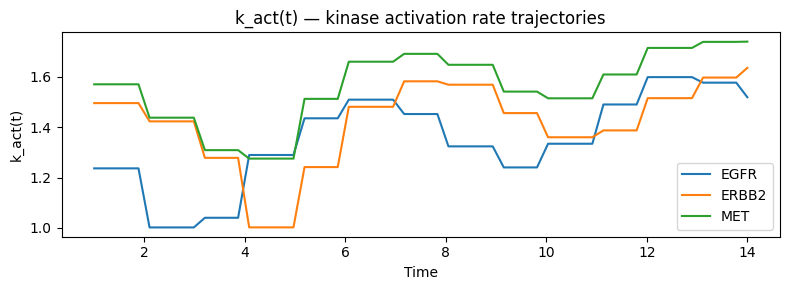

Saved 06_k_act_trajectories.png


In [4]:
fig, ax = plt.subplots(figsize=(8, 3))
for p_idx, pname in enumerate(proteins):
    ax.plot(t_eval, k_act_traj[:, p_idx], label=pname)
ax.set_xlabel("Time"); ax.set_ylabel("k_act(t)")
ax.set_title("k_act(t) — kinase activation rate trajectories")
ax.legend(); fig.tight_layout()
fig.savefig(OUTPUT_DIR / "06_k_act_trajectories.png", dpi=100)
plt.show()
print("Saved 06_k_act_trajectories.png")


## 6  Build `s_prod_fn` and evaluate it

`s_prod_fn` uses:
- `t_protein` — phosphosite/protein time array
- `Y_data` — scaled phosphosite matrix `(N, T)`
- `R_kin_site` — `(M, N)` kinase-site weight matrix
- `kin_to_prot_idx` — `(M,)` kinase→protein mapping

In [5]:
R_kin_site = row_normalize(K_site_kin.T)   # (M, N)
print("R_kin_site:", R_kin_site.shape)

s_prod_fn = make_s_prod_fn(
    t_protein=t_phos,
    Y_data=P_scaled,
    R_kin_site=R_kin_site,
    kin_to_prot_idx=kin_to_prot_idx,
    K=K,
    M=M,
    s_prod_fn_type="bounded",
    interp_mode="piecewise_constant",
)

s_prod_traj = np.array([np.array(s_prod_fn(float(t))) for t in t_eval])
print("s_prod_traj shape:", s_prod_traj.shape, "  (T_eval × K)")
print("Range: [{:.4f}, {:.4f}]".format(s_prod_traj.min(), s_prod_traj.max()))


R_kin_site: (2, 9)
s_prod_traj shape: (60, 3)   (T_eval × K)
Range: [0.1000, 0.1665]


/home/abhinav/Documents/phoscrosstalk/phoscrosstalk/derived_rates.py:739: UserWarning: Explicitly requested dtype float64 requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  prot_signal_j = jnp.asarray(prot_signal, dtype=jnp.float64)
/home/abhinav/Documents/phoscrosstalk/phoscrosstalk/derived_rates.py:740: UserWarning: Explicitly requested dtype float64 requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  times_j = jnp.asarray(times, dtype=jnp.float64)


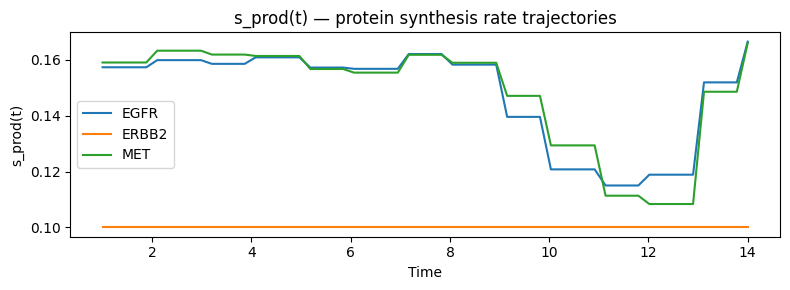

Saved 06_s_prod_trajectories.png


In [6]:
fig, ax = plt.subplots(figsize=(8, 3))
for p_idx, pname in enumerate(proteins):
    ax.plot(t_eval, s_prod_traj[:, p_idx], label=pname)
ax.set_xlabel("Time"); ax.set_ylabel("s_prod(t)")
ax.set_title("s_prod(t) — protein synthesis rate trajectories")
ax.legend(); fig.tight_layout()
fig.savefig(OUTPUT_DIR / "06_s_prod_trajectories.png", dpi=100)
plt.show()
print("Saved 06_s_prod_trajectories.png")


## 7  Transfer functions — why we bound the rates

Raw mRNA or phosphosite values are not directly valid ODE forcing: they can be
negative, zero, or arbitrarily large. A **bounded transfer function** maps any
real input `x` to a finite positive interval `[basal, basal + scale]`.

| `rate_fn_type` | Formula | Output range |
|---|---|---|
| `bounded` | `basal + scale · sigmoid(x)` | `[basal, basal+scale]` |
| `softplus` | `log(1 + exp(x))` | `(0, ∞)` |
| `linear` | `x` (clipped) | depends on clip |
| `positive` | `exp(x)` | `(0, ∞)` |

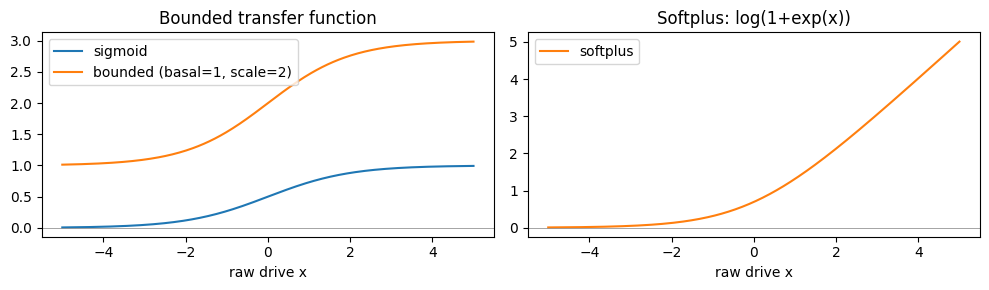

Saved 06_transfer_functions.png


In [7]:
x = np.linspace(-5, 5, 300)
sigmoid  = 1.0 / (1.0 + np.exp(-x))
softplus = np.log1p(np.exp(x))
bounded  = 1.0 + 2.0 * sigmoid   # basal=1.0, scale=2.0

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(x, sigmoid, label="sigmoid")
axes[0].plot(x, bounded, label="bounded (basal=1, scale=2)")
axes[0].set_title("Bounded transfer function"); axes[0].legend()
axes[1].plot(x, softplus, label="softplus", color="tab:orange")
axes[1].set_title("Softplus: log(1+exp(x))"); axes[1].legend()
for ax in axes:
    ax.axhline(0, color="gray", lw=0.5); ax.set_xlabel("raw drive x")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "06_transfer_functions.png", dpi=100)
plt.show()
print("Saved 06_transfer_functions.png")


## 8  Interpolation modes

Inside the JAX-traced ODE, data is interpolated to continuous *t*:

| Mode | Behaviour |
|---|---|
| `piecewise_constant` | Step function — holds last observed value |
| `linear` | Linear interpolation between adjacent time points |

**Piecewise-constant** is the default because it faithfully represents
discrete measurement intervals without over-smoothing.

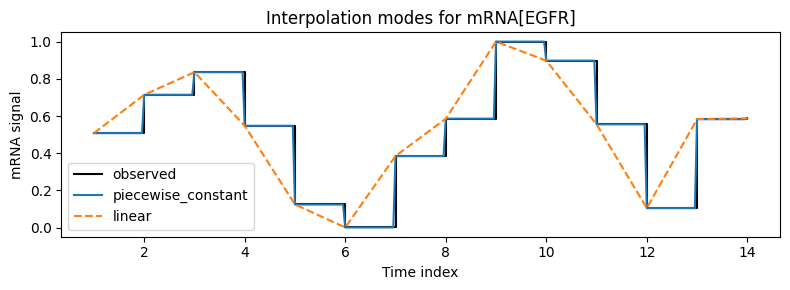

Saved 06_interpolation_modes.png


In [8]:
from scipy.interpolate import interp1d

signal = rna_matrix[0]   # first gene, all time points
t_fine = np.linspace(t_rna[0], t_rna[-1], 300)

def piecewise_constant_interp(t_fine, t_obs, signal):
    idx = np.searchsorted(t_obs, t_fine, side="right") - 1
    return signal[np.clip(idx, 0, len(signal) - 1)]

lin_fn = interp1d(t_rna, signal, kind="linear", fill_value="extrapolate")

fig, ax = plt.subplots(figsize=(8, 3))
ax.step(t_rna, signal, where="post", color="black", lw=1.5, label="observed")
ax.plot(t_fine, piecewise_constant_interp(t_fine, t_rna, signal),
        color="tab:blue",   label="piecewise_constant")
ax.plot(t_fine, lin_fn(t_fine), color="tab:orange", ls="--", label="linear")
ax.set_xlabel("Time index"); ax.set_ylabel("mRNA signal")
ax.set_title(f"Interpolation modes for mRNA[{gene_ids[0]}]")
ax.legend(); fig.tight_layout()
fig.savefig(OUTPUT_DIR / "06_interpolation_modes.png", dpi=100)
plt.show()
print("Saved 06_interpolation_modes.png")


## 9  Null / fallback behaviour

| Scenario | Fallback |
|---|---|
| `tf_prot_weights=None` | `k_act(t)` returns constant `1.0` vector |
| No kinase-site signal | `s_prod(t)` returns constant `0.1` vector |
| RNA data unavailable | Pass `t_rna=None`, `rna_data=None` |

These defaults keep the ODE well-posed even for minimal data configurations.

In [9]:
k_act_null = make_k_act_fn(t_rna=None, rna_data=None, tf_prot_weights=None, K=K)
vals = np.array([np.array(k_act_null(float(t))) for t in t_eval])
print("k_act_null (no TF data) values (first 3 rows):", vals[:3])
assert np.allclose(vals, 1.0), "Expected constant 1.0"
print("✓  k_act_fn with no TF data returns constant 1.0")


k_act_null (no TF data) values (first 3 rows): [[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]
✓  k_act_fn with no TF data returns constant 1.0


/home/abhinav/Documents/phoscrosstalk/phoscrosstalk/derived_rates.py:473: UserWarning: Explicitly requested dtype float64 requested in full is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  _const = jnp.full(K, float(basal), dtype=jnp.float64)
